covid-19 DATA ANALYSIS

Import Librarys

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from dash import Dash, dcc, html

1.Data Collections

In [27]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/country_wise_latest.csv")

df = df[[ "Active","Country/Region", "Confirmed", "Deaths", "Recovered"]]

df.columns = ["Date", "Country", "Confirmed", "Deaths", "Recovered"]

2. Data Cleaning & Preprocessing

In [28]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.isnull().sum())

df.fillna(0, inplace=True)

df.drop_duplicates(inplace=True)

cols = ["Confirmed", "Deaths", "Recovered"]
df[cols] = df[cols].apply(pd.to_numeric)

df["Active"] = df["Confirmed"] - df["Deaths"] - df["Recovered"]

Date         0
Country      0
Confirmed    0
Deaths       0
Recovered    0
dtype: int64


3.Descriptive Statistics

Calculation:

In [29]:
total_confirmed = df["Confirmed"].sum()
total_deaths = df["Deaths"].sum()
total_recovered = df["Recovered"].sum()

print("Total Confirmed:", total_confirmed)
print("Total Deaths:", total_deaths)
print("Total Recovered:", total_recovered)

print(df.describe())

Total Confirmed: 16480485
Total Deaths: 654036
Total Recovered: 9468087
                                Date     Confirmed         Deaths  \
count                            187  1.870000e+02     187.000000   
mean   1970-01-01 00:00:00.000034001  8.813094e+04    3497.518717   
min              1970-01-01 00:00:00  1.000000e+01       0.000000   
25%    1970-01-01 00:00:00.000000141  1.114000e+03      18.500000   
50%    1970-01-01 00:00:00.000001600  5.059000e+03     108.000000   
75%    1970-01-01 00:00:00.000009149  4.046050e+04     734.000000   
max    1970-01-01 00:00:00.002816444  4.290259e+06  148011.000000   
std                              NaN  3.833187e+05   14100.002482   

          Recovered        Active  
count  1.870000e+02  1.870000e+02  
mean   5.063148e+04  3.400194e+04  
min    0.000000e+00  0.000000e+00  
25%    6.265000e+02  1.415000e+02  
50%    2.815000e+03  1.600000e+03  
75%    2.260600e+04  9.149000e+03  
max    1.846641e+06  2.816444e+06  
std    1.901882e+0

4. COVID Trend Analysis

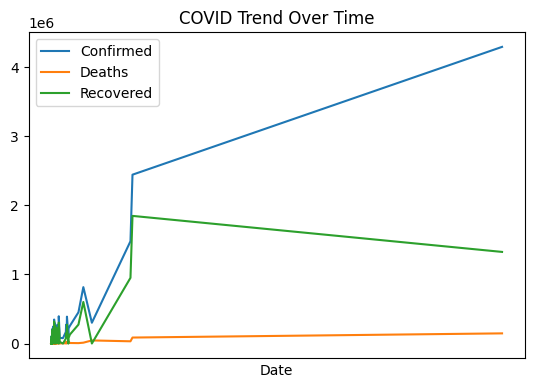

In [30]:
trend = df.groupby("Date")[["Confirmed", "Deaths", "Recovered"]].sum()

trend.plot()
plt.title("COVID Trend Over Time")
plt.show()

5. Country-Based Analysis

In [31]:
country_data = df.groupby("Country")[["Confirmed", "Deaths", "Recovered"]].sum()

top10 = country_data.sort_values(by="Confirmed", ascending=False).head(10)
print(top10)

                Confirmed  Deaths  Recovered
Country                                     
US                4290259  148011    1325804
Brazil            2442375   87618    1846641
India             1480073   33408     951166
Russia             816680   13334     602249
South Africa       452529    7067     274925
Mexico             395489   44022     303810
Peru               389717   18418     272547
Chile              347923    9187     319954
United Kingdom     301708   45844       1437
Iran               293606   15912     255144


6. Dashboard-Based Analysis (Plotly Dash)

In [32]:
!pip install dash

In [34]:
app = Dash(__name__)

app.layout = html.Div([
    html.H1("COVID Dashboard"),

    dcc.Dropdown(
        id="country",
        options=[{"label": c, "value": c} for c in df["Country"].unique()],
        value="India"
    ),

    dcc.Graph(id="graph")
])

7. Relationship Analysis

           Confirmed    Deaths  Recovered    Active
Confirmed   1.000000  0.934698   0.906377  0.927018
Deaths      0.934698  1.000000   0.832098  0.871586
Recovered   0.906377  0.832098   1.000000  0.682103
Active      0.927018  0.871586   0.682103  1.000000


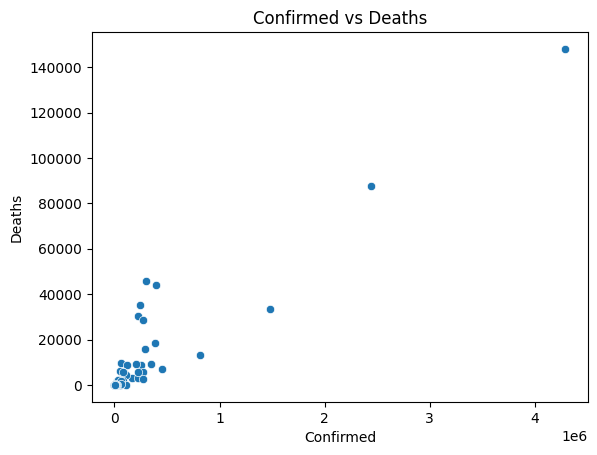

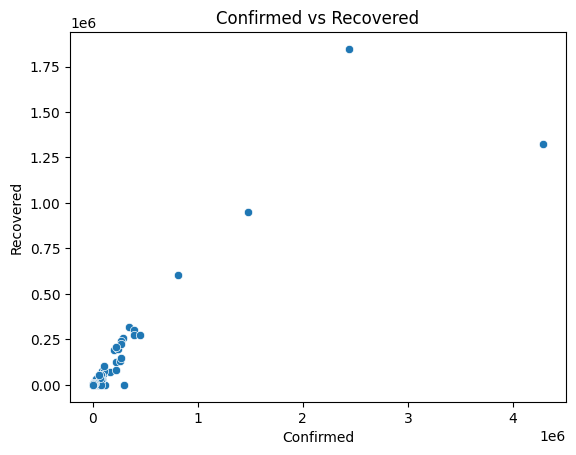

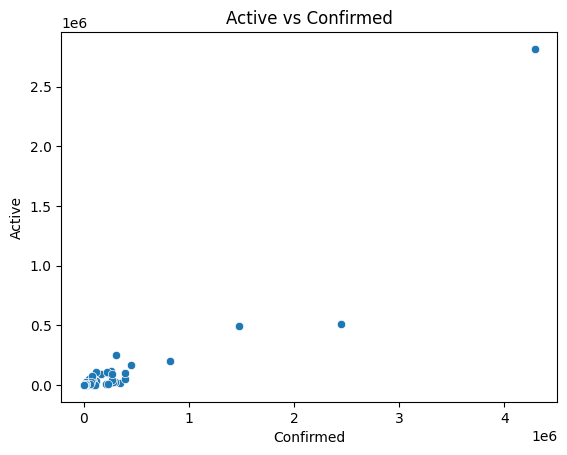

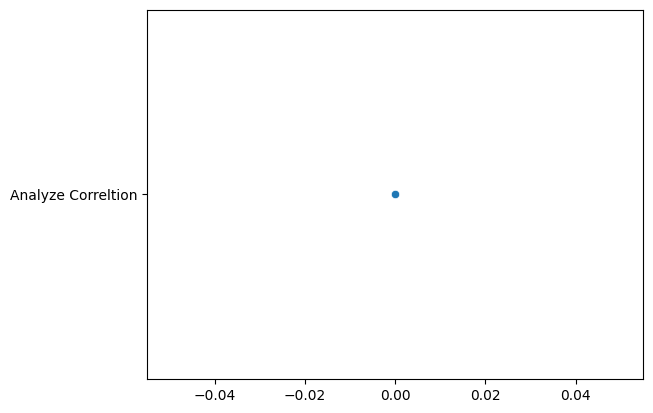

In [36]:
corr = df[["Confirmed", "Deaths", "Recovered", "Active"]].corr()
print(corr)


sns.scatterplot(x="Confirmed", y="Deaths", data=df)
plt.title("Confirmed vs Deaths")
plt.show()



sns.scatterplot(x="Confirmed", y="Recovered", data=df)
plt.title("Confirmed vs Recovered")
plt.show()



sns.scatterplot(x="Confirmed", y="Active", data=df)
plt.title("Active vs Confirmed")
plt.show()



sns.scatterplot("Analyze Correltion")
plt.show()

8. Data Visualization

.Line

In [37]:

px.line(df, x="Date", y="Confirmed").show()


.Bar Chart

In [38]:

top10 = df.groupby("Country")["Confirmed"].sum().nlargest(10).reset_index()
px.bar(top10, x="Country", y="Confirmed").show()


.Pie Chart

In [39]:

latest = df.iloc[-1]
px.pie(names=["Confirmed","Deaths","Recovered"],
       values=[latest["Confirmed"],latest["Deaths"],latest["Recovered"]]).show()


.Scatter Plot

In [40]:

px.scatter(df, x="Confirmed", y="Deaths").show()



.Heatmap

In [41]:

px.imshow(corr, text_auto=True).show()

9. Dashboard Insights (Code)


🔹 Identify High-Risk Countries

In [52]:
df.columns = df.columns.str.strip()

print(df.columns)

top_countries = df.groupby("Country")["Confirmed"].max().sort_values(ascending=False).head(10)

fig1 = px.bar(
    x=top_countries.index,
    y=top_countries.values,
    title="Top 10 Countries by Confirmed Cases"
)

fig1.show()

Index(['Date', 'Country', 'Confirmed', 'Deaths', 'Recovered', 'Active'], dtype='object')


🔹 Analyze Recovery Trends

In [53]:

recovery_trend = df.groupby("Date")["Recovered"].sum().reset_index()

fig2 = px.line(recovery_trend,
               x="Date",
               y="Recovered",
               title="Global Recovery Trend Over Time")
fig2.show()

🔹 Observe Pandemic Patterns

In [54]:

df["Active"] = df["Confirmed"] - df["Recovered"] - df["Deaths"]

active_trend = df.groupby("Date")["Active"].sum().reset_index()

fig3 = px.line(active_trend,
               x="Date",
               y="Active",
               title="Active Cases Trend (Pandemic Pattern)")
fig3.show()

10. Insights & Conclusion

In [56]:
print("\n INSIGHTS & CONCLUSION:")
print("1. Top countries show highest COVID impact.")
print("2. Confirmed cases trend shows spread pattern.")
print("3. Recovery rate indicates healthcare improvement.")
print("4. Death rate shows severity over time.")
print("5. Active cases help understand current pandemic load.")


 INSIGHTS & CONCLUSION:
1. Top countries show highest COVID impact.
2. Confirmed cases trend shows spread pattern.
3. Recovery rate indicates healthcare improvement.
4. Death rate shows severity over time.
5. Active cases help understand current pandemic load.
